Select your Google Earth image (mapa_base_real.png):


Saving mapa_base_real.png to mapa_base_real (3).png
File uploaded: mapa_base_real (3).png
1. Analyzing real geography and creating land mask...
2. Generating coherent synthetic topography...
3. Generating digital cartography...


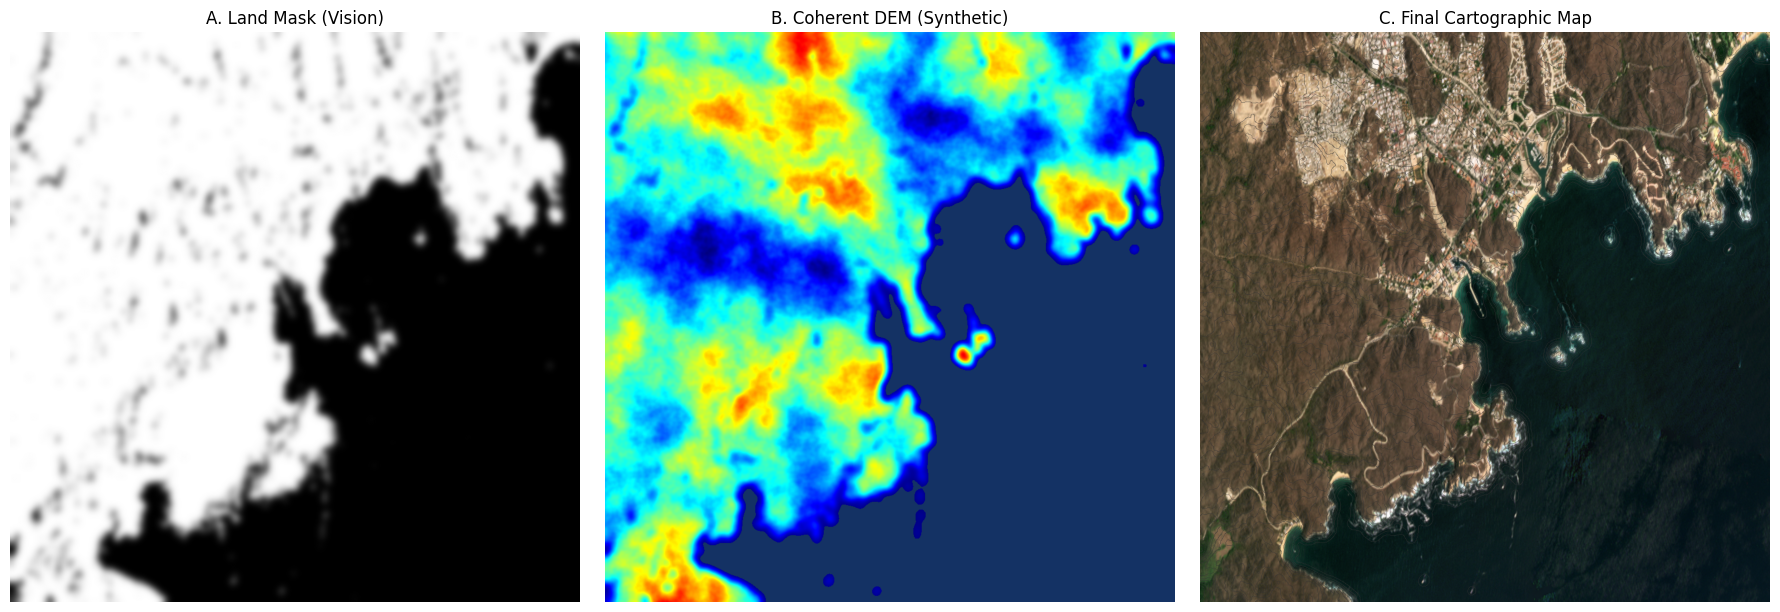

In [6]:
# ==========================================
# 0. INSTALLATION AND FILE UPLOAD
# ==========================================
!pip install noise -q

import numpy as np
import matplotlib.pyplot as plt
import noise
from PIL import Image
import cv2
import os
from google.colab import files
import os

# Create folder
output_path = '/content/drive/MyDrive/Vision_Artificial_Veracruz'
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Save with dynamic names (to avoid overwriting)
import time
timestamp = time.strftime("%Y%m%d-%H%M%S")

cv2.imwrite(f'{output_path}/DEM_{timestamp}.png', (dem_final * 255).astype(np.uint8))
cv2.imwrite(f'{output_path}/MapaFinal_{timestamp}.png', cv2.cvtColor(mapa_hibrido, cv2.COLOR_BGR2RGB))

print("Select your Google Earth image (mapa_base_real.png):")
uploaded = files.upload()

# Get the name of the uploaded file dynamically
if uploaded:
    PATH_MAPA_BASE = list(uploaded.keys())[0]
    print(f"File uploaded: {PATH_MAPA_BASE}")
else:
    raise Exception("No file was uploaded.")

# ==========================================
# 1. PARAMETER CONFIGURATION
# ==========================================

# Perlin Noise Parameters (Imaginary Topography)
SHAPE = (1024, 1024)
SCALE = 250.0        # Adjusted for smoother slopes typical of Veracruz
OCTAVES = 6
PERSISTENCE = 0.5
LACUNARITY = 2.0
SEED = 42

# Cartographic Parameters
N_CONTOURS = 15
CONTOUR_COLOR = (50, 50, 50)
ALPHA_OVERLAY = 0.6

# ==========================================
# 2. PROCESSING FUNCTIONS
# ==========================================

def create_land_mask(image_path, shape):
    """Analyzes the real map to separate land from sea."""
    img = cv2.imread(image_path)
    img = cv2.resize(img, (shape[1], shape[0]))

    # Convert to grayscale to detect the sea (darker areas)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Thresholding: Sea is usually < 50 in intensity
    _, mask_sea = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY_INV)
    mask_land = cv2.bitwise_not(mask_sea)

    # Smooth so the coast is not abrupt
    mask_land_smooth = cv2.GaussianBlur(mask_land, (41, 41), 0)
    return mask_land_smooth.astype(np.float32) / 255.0, img

def generate_guided_perlin(shape, scale, octaves, persistence, lacunarity, seed, mask):
    """Generates Perlin noise multiplied by the land mask."""
    width, height = shape
    matrix = np.zeros(shape)

    for i in range(width):
        for j in range(height):
            matrix[i][j] = noise.pnoise2(i/scale, j/scale, octaves=octaves,
                                        persistence=persistence, lacunarity=lacunarity,
                                        repeatx=width, repeaty=height, base=seed)

    # Normalize
    matrix = (matrix - np.min(matrix)) / (np.max(matrix) - np.min(matrix))

    # APPLY MASK: Elevation only exists on land
    return matrix * mask

def create_contour_overlay(dem, shape, n_contours, contour_color):
    """Creates the topographic contour lines layer."""
    dem_8bit = (dem * 255).astype(np.uint8)
    contour_image = np.zeros((shape[0], shape[1], 3), dtype=np.uint8)

    blurred_dem = cv2.GaussianBlur(dem_8bit, (5,5), 0)
    levels = np.linspace(5, 250, n_contours) # Avoid level 0 (sea)

    for level in levels:
        _, mask = cv2.threshold(blurred_dem, int(level), 255, cv2.THRESH_BINARY)
        edged = cv2.Canny(mask, 30, 150)
        contours_cv, _ = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(contour_image, contours_cv, -1, contour_color, 1)

    return contour_image

# ==========================================
# 3. EXECUTION
# ==========================================

print("1. Analyzing real geography and creating land mask...")
mask_guia, mapa_base = create_land_mask(PATH_MAPA_BASE, SHAPE)

print("2. Generating coherent synthetic topography...")
dem_final = generate_guided_perlin(SHAPE, SCALE, OCTAVES, PERSISTENCE, LACUNARITY, SEED, mask_guia)

print("3. Generating digital cartography...")
capa_contornos = create_contour_overlay(dem_final, SHAPE, N_CONTOURS, CONTOUR_COLOR)

# Overlay
mask_contornos = cv2.cvtColor(capa_contornos, cv2.COLOR_BGR2GRAY)
_, mask_inv = cv2.threshold(mask_contornos, 1, 255, cv2.THRESH_BINARY_INV)
mapa_base_bg = cv2.bitwise_and(mapa_base, mapa_base, mask=mask_inv)
contornos_fg = cv2.bitwise_and(capa_contornos, capa_contornos, mask=mask_contornos)
mapa_hibrido = cv2.addWeighted(mapa_base, 1 - ALPHA_OVERLAY, cv2.add(mapa_base_bg, contornos_fg), ALPHA_OVERLAY, 0)

# ==========================================
# 4. RESULTS
# ==========================================
dem_color = cv2.applyColorMap((dem_final * 255).astype(np.uint8), cv2.COLORMAP_JET)
# Paint the sea blue in the colormap
dem_color[mask_guia < 0.05] = [100, 50, 20]

plt.figure(figsize=(18, 6))
titles = ["A. Land Mask (Vision)", "B. Coherent DEM (Synthetic)", "C. Final Cartographic Map"]
imgs = [mask_guia, cv2.cvtColor(dem_color, cv2.COLOR_BGR2RGB), cv2.cvtColor(mapa_hibrido, cv2.COLOR_BGR2RGB)]

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.title(titles[i])
    plt.imshow(imgs[i], cmap='gray' if i==0 else None)
    plt.axis('off')

plt.tight_layout()
plt.show()
